# Test predict-then-optimise baselines

This notebook is a small end-to-end smoke test for `models/src/pto_baselines.py`: load the macro and charge-off data, fit the linear and MLP PTO models on an expanding-window sample

In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import importlib
import capital_allocation_utils
import pto_baselines


ROOT = Path.cwd().resolve()

while ROOT != ROOT.parent and not (ROOT / "models" / "src" / "pto_baselines.py").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "models" / "src"))

importlib.reload(capital_allocation_utils)
importlib.reload(pto_baselines)

from capital_allocation_utils import (
    CapitalConfig,
    ModelConfig,
    chronological_split,
    load_and_align_data,
)

from pto_baselines import (
    PTOForecaster,
    build_prediction_frame,
    evaluate_predictions,
    predict_p,
    run_expanding_window,
    run_holdout,
    train_pto_model,
)

## Load and align data

`macro_panel_quarterly.csv` is dated at quarter end, while `fred_loan_return_aligned.csv` is dated at quarter start. The temporary macro copy below converts macro dates to quarter start before using the baseline `load_and_align_data` function.

In [3]:
macro_csv = ROOT / "data" / "processed" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "data" / "processed" / "fred_loan_return_aligned.csv"
results_dir = ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

macro = pd.read_csv(macro_csv)
macro["DATE"] = pd.to_datetime(macro["DATE"]).dt.to_period("Q").dt.start_time
macro_aligned_csv = ROOT / "data/processed/" "macro_panel_quarter_start.csv"
macro.to_csv(macro_aligned_csv, index=False)


df = load_and_align_data(
    macro_csv=macro_aligned_csv,
    chargeoff_csv=chargeoff_csv,
    date_col="DATE",
    target_col="charge_off_rate",
    feature_cols=None,
    horizon=1,
    target_is_percent=True,
)

feature_cols = df.attrs["feature_cols"]
print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Date range: {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

display(df.head())

Observations after alignment and one-step target: 143
Date range: 1990-04-01 to 2025-10-01
Features (12): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium']


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium,charge_off_rate,target_date,target_chargeoff_next
0,1990-04-01,1.500000,5.333333,0.684295,0.736741,0.984464,0.423064,8.243333,0.103016,18.722063,1.638730,54.400000,0.146990,0.014300,1990-07-01,0.012800
1,1990-07-01,0.300000,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,1.706190,46.700000,-0.047302,0.012800,1990-10-01,0.013000
2,1990-10-01,-3.600000,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,2.197419,54.200000,0.266956,0.013000,1991-01-01,0.014800
3,1991-01-01,-1.900000,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,2.186500,38.600000,0.305454,0.014800,1991-04-01,0.018600
4,1991-04-01,3.200000,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,1.795937,20.000000,0.162705,0.018600,1991-07-01,0.019700


## Rolling Window Evaluation

In [6]:

cap_cfg = CapitalConfig(
    leverage=5.0,
    y_bar=0.05, 
    lambda_penalty=10,
)

expanding_cfg = ModelConfig(
    hidden_dim=16,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=16,
    epochs=500,
    patience=75,
    val_frac=0.2,
    seed=42,
)

pto_expanding_predictions, pto_expanding_history = run_expanding_window(
    df=df,
    date_col="DATE",
    feature_cols=feature_cols,
    initial_train_frac=0.75,
    model_cfg=expanding_cfg,
    cap_cfg=cap_cfg,
    return_history=True,
)

display(pto_expanding_predictions.head())

Initial train observations: 107 | Expanding-window test observations: 36
  expanding step 1/36: train through index 106, test index 107
    fitting linear PTO model...
    linear epoch    1 | val mse 0.00004075 | val regret 0.038499 | mean p 0.4331 | mean alpha 0.6232
    fitting mlp PTO model...
    mlp    epoch    1 | val mse 0.00004399 | val regret 0.039240 | mean p 0.4605 | mean alpha 0.6201
    mlp    epoch  100 | val mse 0.00002676 | val regret 0.032469 | mean p 0.2702 | mean alpha 0.6486
    mlp    epoch  200 | val mse 0.00002664 | val regret 0.030953 | mean p 0.2527 | mean alpha 0.6550
  expanding step 10/36: train through index 115, test index 116
    fitting linear PTO model...
    linear epoch    1 | val mse 0.00005861 | val regret 0.043043 | mean p 0.5405 | mean alpha 0.6132
    linear epoch  100 | val mse 0.00004225 | val regret 0.039449 | mean p 0.3973 | mean alpha 0.6284
    linear epoch  200 | val mse 0.00003328 | val regret 0.036684 | mean p 0.3053 | mean alpha 0.6401


,feature_date,target_date,model,eval_mode,realised_chargeoff,p_hat_stress,mu_hat_chargeoff,pd_hat_annualised,k_irb_hat,alpha_hat,alpha_oracle,realised_utility,oracle_utility,regret
0,2017-01-01,2017-04-01,linear,expanding,0.003700,0.464176,0.009906,0.085190,0.145461,0.619734,0.772890,1.143468,1.178924,0.035456
1,2017-01-01,2017-04-01,mlp,expanding,0.003700,0.014823,0.006222,0.054166,0.123183,0.691602,0.772890,1.160106,1.178924,0.018818
2,2017-04-01,2017-07-01,linear,expanding,0.003400,0.442570,0.009729,0.083716,0.144504,0.621889,0.781137,1.144900,1.182005,0.037105
3,2017-04-01,2017-07-01,mlp,expanding,0.003400,0.001104,0.006109,0.053207,0.122429,0.695223,0.781137,1.161987,1.182005,0.020018
4,2017-07-01,2017-10-01,linear,expanding,0.003600,0.055648,0.006556,0.057017,0.125403,0.679428,0.775584,1.157627,1.179936,0.022308


## Plot Rolling Evaluation Panel

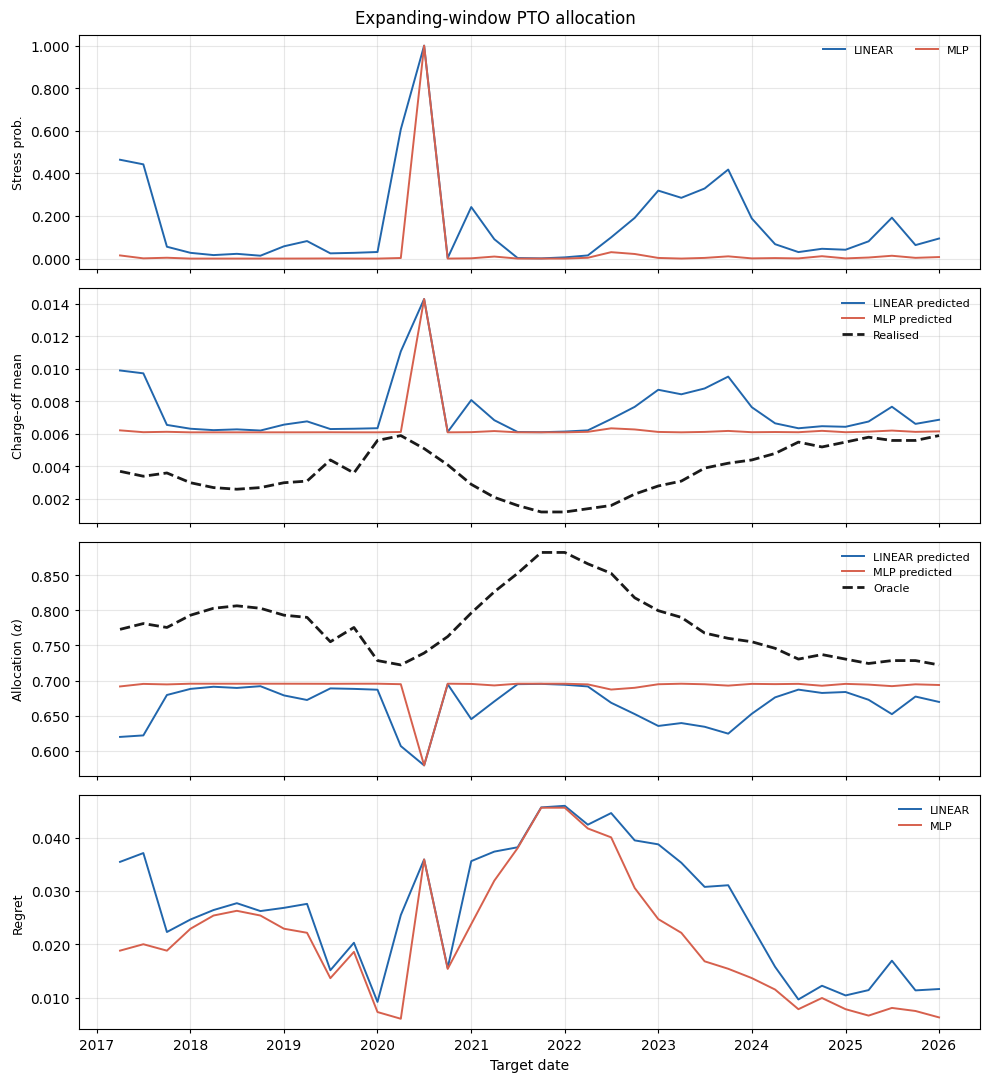

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

MODEL_COLORS = {"linear": "#2166ac", "mlp": "#d6604d"}
ORACLE_COLOR = "#1a1a1a"

pto_expanding_predictions["target_date"] = pd.to_datetime(
    pto_expanding_predictions["target_date"]
)

fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
fig.subplots_adjust(hspace=0.08)

# ── Per-model lines ────────────────────────────────────────────────────────
for model_name, group in pto_expanding_predictions.groupby("model"):
    group = group.sort_values("target_date")
    color = MODEL_COLORS.get(model_name, "grey")
    label = model_name.upper()

    axes[0].plot(group["target_date"], group["p_hat_stress"],
                 color=color, lw=1.4, label=f"{label}")
    axes[1].plot(group["target_date"], group["mu_hat_chargeoff"],
                 color=color, lw=1.4, label=f"{label} predicted")
    axes[2].plot(group["target_date"], group["alpha_hat"],
                 color=color, lw=1.4, label=f"{label} predicted")
    axes[3].plot(group["target_date"], group["regret"],
                 color=color, lw=1.4, label=f"{label}")

# ── Oracle / realised lines ────────────────────────────────────────────────
oracle = (
    pto_expanding_predictions[pto_expanding_predictions["model"] == "linear"]
    .sort_values("target_date")
)

axes[1].plot(oracle["target_date"], oracle["realised_chargeoff"],
             color=ORACLE_COLOR, lw=2, ls="--", label="Realised")
axes[2].plot(oracle["target_date"], oracle["alpha_oracle"],
             color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")



# ── Axis labels & formatting ───────────────────────────────────────────────
ylabels = ["Stress prob.", "Charge-off mean", r"Allocation ($\alpha$)", "Regret"]
for ax, ylabel in zip(axes, ylabels):
    ax.set_ylabel(ylabel, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, frameon=False, loc="upper right",
              ncol=2 if ax == axes[0] else 1)

axes[3].set_xlabel("Target date", fontsize=10)
axes[3].xaxis.set_major_locator(mdates.YearLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Expanding-window PTO allocation", fontsize=12)
plt.tight_layout()

plt.savefig("figures/PTO_rolling_panel_results.png", dpi=200, bbox_inches="tight")
plt.show()

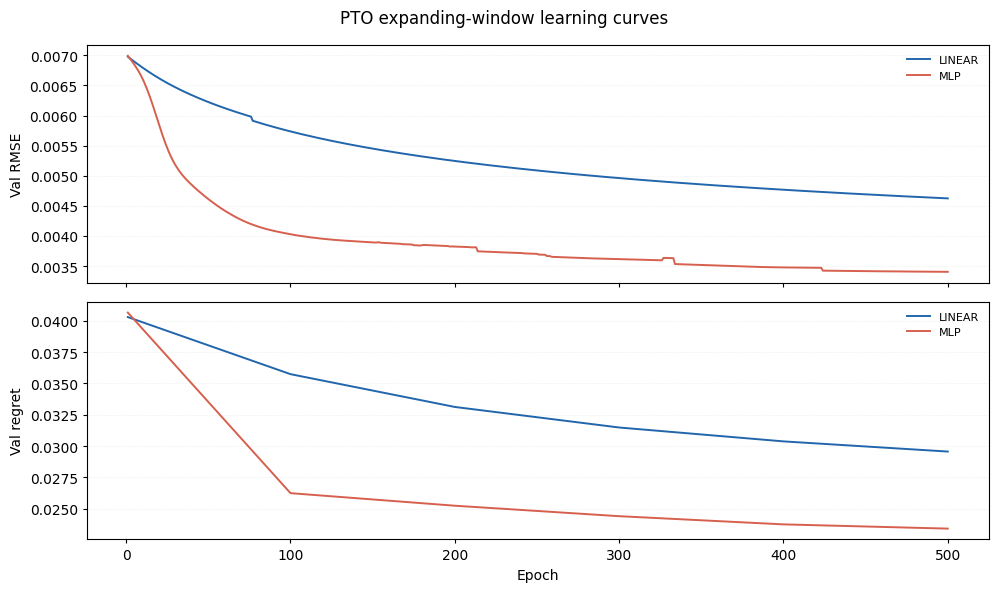

In [29]:
plt.rcdefaults()

plt.rcParams.update({
    "font.size": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

MODEL_COLORS = {"linear": "#2166ac", "mlp": "#d6604d"}

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.subplots_adjust(hspace=0.08)

for model_name, group in mean_history.groupby("model"):
    group = group.sort_values("epoch")
    axes[0].plot(
        group["epoch"],
        group["mean_val_rmse"],
        color=MODEL_COLORS.get(model_name, "grey"),
        lw=1.4,
        label=model_name.upper(),
    )

for model_name, group in regret_history.groupby("model"):
    group = group.sort_values("epoch")
    axes[1].plot(
        group["epoch"],
        group["mean_val_regret"],
        color=MODEL_COLORS.get(model_name, "grey"),
        lw=1.4,
        label=model_name.upper(),
    )

axes[0].set_ylabel("Val RMSE")
axes[1].set_ylabel("Val regret")
axes[1].set_xlabel("Epoch")

for ax in axes:
    ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":")
    ax.legend(fontsize=8, frameon=False, loc="upper right")

fig.suptitle("PTO expanding-window learning curves", fontsize=12)
plt.tight_layout()
plt.savefig("figures/PTO_learning_curves.png", dpi=200, bbox_inches="tight")
plt.show()

# Test Distribution

In [12]:
	
df = load_and_align_data(
    macro_csv=macro_aligned_csv,
    chargeoff_csv=chargeoff_csv,
    date_col="DATE",
    target_col="charge_off_rate",
    feature_cols=None,
    horizon=1,
    target_is_percent=True,
)

train_frac = 0.75
train_df, test_df = chronological_split(df, train_frac=train_frac)


In [13]:
print("Train target summary:")
display(train_df["target_chargeoff_next"].describe())

print("Test target summary:")
display(test_df["target_chargeoff_next"].describe())

print("Current mixture params:")
print("mu_normal:", cap_cfg.mu_normal)
print("mu_stress:", cap_cfg.mu_stress)
print("sigma_normal:", cap_cfg.sigma_normal)
print("sigma_stress:", cap_cfg.sigma_stress)

print("Share of train target below mu_normal:")
print((train_df["target_chargeoff_next"] < cap_cfg.mu_normal).mean())

print("Share of test target below mu_normal:")
print((test_df["target_chargeoff_next"] < cap_cfg.mu_normal).mean())

Train target summary:


count   107.000000
mean      0.007833
std       0.006247
min       0.001200
25%       0.003050
50%       0.005400
75%       0.012550
max       0.025700
Name: target_chargeoff_next, dtype: float64

Test target summary:


count   36.000000
mean     0.003697
std      0.001472
min      0.001200
25%      0.002700
50%      0.003600
75%      0.005125
max      0.005900
Name: target_chargeoff_next, dtype: float64

Current mixture params:
mu_normal: 0.0061
mu_stress: 0.0143
sigma_normal: 0.0042
sigma_stress: 0.0067
Share of train target below mu_normal:
0.5700934579439252
Share of test target below mu_normal:
1.0


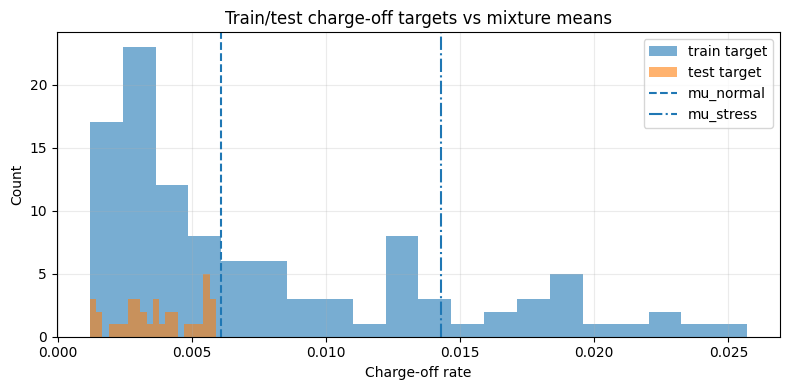

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    train_df["target_chargeoff_next"],
    bins=20,
    alpha=0.6,
    label="train target",
)

ax.hist(
    test_df["target_chargeoff_next"],
    bins=20,
    alpha=0.6,
    label="test target",
)

ax.axvline(cap_cfg.mu_normal, linestyle="--", label="mu_normal")
ax.axvline(cap_cfg.mu_stress, linestyle="dashdot", label="mu_stress")

ax.set_xlabel("Charge-off rate")
ax.set_ylabel("Count")
ax.set_title("Train/test charge-off targets vs mixture means")
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('figures/test_distribution.png')
plt.show()


## Save optional outputs

This gives you a small CSV to inspect or compare against future expanding-window results.

In [ ]:
output_csv = scratch_dir / "pto_baseline_smoke_test_predictions.csv"
predictions.to_csv(output_csv, index=False)
print(f"Saved predictions to {output_csv.relative_to(ROOT)}")